# Task: Reversing names
* Our task will be to reverse a name, e.g.:
   * sophia -> aihpos
* To make the model learn an additional simple pattern, we'll also add a noise character after each character of the input, e.g.:

  * suorpxhziwa -> aihpos
* As a spoiler, we'll be able to see the model attending to non-noise characters.

In [10]:
names = open('names.txt', 'r').read().splitlines()
names[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [11]:
vocab = sorted(list(set(''.join(names))))
vocab.append('<S>')
vocab.append('<PAD>')
token_to_index = {c : i for i, c in enumerate(vocab)}
index_to_token = {i : c for c, i in token_to_index.items()}

print(len(vocab))

28


In [12]:
vocab_size = len(vocab)

In [114]:
import torch
import torch.nn.functional as F
g = torch.Generator().manual_seed(10000)

# The task is to reverse the input
# The input also has a 'noise' token after each token
# The output does not have the noise token

def build_dataset(data):
    X, Yin, Yout = [], [], []
    for item in data:
        # The task is to reverse the input
        # The input also has a 'noise' token after each token
        # The output does not have the noise token
        x_tokens = []
        for token in item:
            x_tokens.append(token)
            # Random character
            x_tokens.append(random.choice('abcdefghijklmnopqrstuvwxyz'))
        y_tokens = ['<S>'] + list(reversed(item)) + ['<S>']

        x_indices = [token_to_index[token] for token in x_tokens]
        y_indices = [token_to_index[token] for token in y_tokens]
        X.append(x_indices)
        Yin.append(y_indices[:-1])
        Yout.append(y_indices[1:])
    return X, Yin, Yout

# Split into train, dev, test
import random
random.seed(123)
random.shuffle(names)

n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))

X_train, Yin_train, Yout_train = build_dataset(names[:n1])
X_dev, Yin_dev, Yout_dev = build_dataset(names[n1:n2])
X_test, Yin_test, Yout_test = build_dataset(names[n2:])
len(X_train), len(Yin_train), len(Yout_train)

(25626, 25626, 25626)

### Walking through simple attention

In [115]:
B = 1
Tx = 10
Ty = 6
D = 32

# This is like the encoder hidden states
keys = torch.randn((B, Tx, D), generator=g)
values = keys

# This is like the current hidden state of the decoder
query = torch.randn((B, Ty, D), generator=g)

print(f'{keys.size() = }, {query.size() = }')

# Dot product attention
# (B, Tx, D) x (B, D, 1) -> (B, Tx, 1)
e = torch.bmm(keys, query.transpose(1, 2)) # scores
alpha = torch.softmax(e, dim=1) # attention weights
print(f'{alpha.size() = }')

context = torch.bmm(alpha.transpose(1, 2), values) # (B, D)
print(f'{context.size() = }')

out = torch.cat([query, context], dim=2)
probs = torch.softmax(out, dim=2)
probs.sum(2, keepdim=True)

keys.size() = torch.Size([1, 10, 32]), query.size() = torch.Size([1, 6, 32])
alpha.size() = torch.Size([1, 10, 6])
context.size() = torch.Size([1, 6, 32])


tensor([[[1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [1.0000],
         [1.0000]]])

In [116]:
alpha.sum(dim=1)

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])

### Building the Encoder-Decoder with Attention

In [130]:
import torch.nn as nn

class DotAttention(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, query, key, value):
        # query: (B, Ty, D)
        # keys: (B, Tx, D)
        # values: (B, Tx, D)
        dot = torch.bmm(key, query.transpose(1, 2)) 
        weights = torch.softmax(dot, dim=1)
        out = torch.bmm(weights.transpose(1, 2), value)
        return out, weights

class EncoderDecoder(nn.Module):
    def __init__(self, vocab_size, emb_size, hidden_size):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_size)
        self.encoder = nn.GRU(emb_size, hidden_size, batch_first=True)
        self.decoder = nn.GRU(emb_size, hidden_size, batch_first=True)
        self.attention = DotAttention()
        self.query = nn.Linear(hidden_size, hidden_size)
        
        # Output layer
        self.out = nn.Linear(hidden_size * 2, vocab_size)
        
        self.hidden_size = hidden_size
        
    def forward(self, X, Yin):
        # Encode
        X_embed = self.emb(X)
        Henc, henc_last = self.encoder(X_embed)
        # print(f'{Henc.shape = }, {henc_last.shape = }')
        
        # Decode
        Yin_embed = self.emb(Yin)
        Hdec, _ = self.decoder(Yin_embed, henc_last)
        # print(f'{Hdec.shape = }')
        
        # Attention
        query = self.query(Hdec)
        # print(f'{query.shape = }')
        context, _ = self.attention(query, Henc, Henc)
        # print(f'{context.shape = }')
        
        # Combine
        out = torch.cat([Hdec, context], dim=2)
        out = self.out(out)
        return out

    def generate(self, x, max_length = 20):
        # Encode
        x_embed = self.emb(x)
        Henc, h = self.encoder(x_embed)
        
        value = Henc
        # Initialize the decoder with the start token
        token = torch.tensor([[token_to_index['<S>']]])
        
        result = []
        attentions = []
        for i in range(max_length):
            # Decode
            token_embed = self.emb(token)
            Hdec, h = self.decoder(token_embed, h)
            query = self.query(Hdec)
            context, scores = self.attention(query, Henc, value)
            
            # Output
            out = torch.cat([Hdec, context], dim=2)
            out = self.out(out)
            
            # Select next token (greedy decoding)
            token = torch.argmax(out, dim=2)
            result.append(token.item())
            attentions.append(scores)
            
            if token[0].item() == token_to_index['<S>']:
                break

        return result, attentions

In [131]:
model = EncoderDecoder(vocab_size, emb_size=32, hidden_size=32)

### Padding according to the max length in the batch

In [132]:
def pad_batch(X, Yin, Yout):
    max_len_x = max(len(x) for x in X)
    max_len_y = max(len(y) for y in Yin)
    X_pad = torch.tensor([x + [token_to_index['<PAD>']] * (max_len_x - len(x)) for x in X])
    Yin_pad = torch.tensor([y + [token_to_index['<PAD>']] * (max_len_y - len(y)) for y in Yin])
    Yout_pad = torch.tensor([y + [token_to_index['<PAD>']] * (max_len_y - len(y)) for y in Yout])
    return X_pad, Yin_pad, Yout_pad

xp, yip, yop = pad_batch(X_train[:3], Yin_train[:3], Yout_train[:3])
xp, yip, yop

(tensor([[ 2, 20,  7, 15, 14, 21,  8, 23,  2, 23,  4, 17],
         [10,  1,  8, 14,  4, 11, 14, 21, 13, 22, 27, 27],
         [13,  5, 24, 22,  9, 22,  0,  4,  4,  7, 27, 27]]),
 tensor([[26,  4,  2,  8, 14,  7,  2],
         [26, 13, 14,  4,  8, 10, 27],
         [26,  4,  0,  9, 24, 13, 27]]),
 tensor([[ 4,  2,  8, 14,  7,  2, 26],
         [13, 14,  4,  8, 10, 26, 27],
         [ 4,  0,  9, 24, 13, 26, 27]]))

### Just testing :)

In [133]:
out = model(xp[:1], yip[:1])
print(f'{out.shape = }')
token = out.argmax(dim=2)

outs = []
for i in token[0]:
    outs.append(index_to_token[i.item()])
    
''.join(outs)

out.shape = torch.Size([1, 7, 28])


'qemmqqk'

### Training and Evaluation

In [134]:
import torch.optim as optim

model = EncoderDecoder(vocab_size, emb_size=32, hidden_size=32)
# Count model parameters
print(f"Model parameters: {sum(p.numel() for p in model.parameters())}")

# Hyperparameters
learning_rate = 0.001
num_epochs = 10
batch_size = 8

# Loss function and optimizer
# NOTE: We ignore the loss whenever the target token is a padding token
criterion = nn.CrossEntropyLoss(ignore_index=token_to_index['<PAD>'])

optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate schedule (cosine)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

# Training loop
for epoch in range(num_epochs):
    # Reshuffle the data
    perm = torch.randperm(len(X_train))
    X_train = [X_train[i] for i in perm]
    Yin_train = [Yin_train[i] for i in perm]
    Yout_train = [Yout_train[i] for i in perm]
    
    model.train()
    total_loss = 0
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        Yin_batch = Yin_train[i:i+batch_size]
        Yout_batch = Yout_train[i:i+batch_size]

        # Pad batch
        X_batch, Yin_batch, Yout_batch = pad_batch(X_batch, Yin_batch, Yout_batch)

        # Forward
        outputs = model(X_batch, Yin_batch)
        outputs = outputs.view(-1, vocab_size) # [batch_size * seq_len, vocab_size]
        Y_batch = Yout_batch.view(-1)
        loss = criterion(outputs, Y_batch)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        total_loss += loss.item()
        
    # Scheduler step
    scheduler.step()

    avg_loss = total_loss / (len(X_train) // batch_size)
    print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

    # Evaluate validation loss
    eval_loss = 0
    model.eval()
    with torch.no_grad():
        for i in range(0, len(X_dev), batch_size):
            X_batch = X_dev[i:i+batch_size]
            Yin_batch = Yin_dev[i:i+batch_size]
            Yout_batch = Yout_dev[i:i+batch_size]
            # Pad batch 
            X_batch, Yin_batch, Yout_batch = pad_batch(X_batch, Yin_batch, Yout_batch)
            outputs = model(X_batch, Yin_batch)

            outputs = outputs.view(-1, vocab_size)
            Y_batch = Yout_batch.view(-1)
            loss = criterion(outputs, Y_batch)

            eval_loss += loss.item()
    avg_eval_loss = eval_loss / (len(X_dev) // batch_size)
    print(f'Epoch [{epoch+1}/{num_epochs}], Validation Loss: {avg_eval_loss:.4f}')

Model parameters: 16444
Epoch [1/10], Loss: 1.1106
Epoch [1/10], Validation Loss: 0.2606
Epoch [2/10], Loss: 0.0994
Epoch [2/10], Validation Loss: 0.0467
Epoch [3/10], Loss: 0.0390
Epoch [3/10], Validation Loss: 0.0493
Epoch [4/10], Loss: 0.0209
Epoch [4/10], Validation Loss: 0.0253
Epoch [5/10], Loss: 0.0116
Epoch [5/10], Validation Loss: 0.0125
Epoch [6/10], Loss: 0.0077
Epoch [6/10], Validation Loss: 0.0083
Epoch [7/10], Loss: 0.0045
Epoch [7/10], Validation Loss: 0.0109
Epoch [8/10], Loss: 0.0021
Epoch [8/10], Validation Loss: 0.0028
Epoch [9/10], Loss: 0.0010
Epoch [9/10], Validation Loss: 0.0018
Epoch [10/10], Loss: 0.0006
Epoch [10/10], Validation Loss: 0.0016


### Sampling from the model

In [135]:
model.eval()
with torch.no_grad():
    for i in range(5):
        x = torch.tensor([X_test[i]])
        y, _ = model.generate(x)
        y = ''.join([index_to_token[i] for i in y])
        # Remove <S> from the end of y
        y = y.split('<S>')[0]

        # Print original and generated names
        print(names[n2+i], end=' -> ')
        print(y)
        # Check if it was reversed correctly
        correct = names[n2+i][::-1] == y
        print('Correct' if correct else 'Incorrect')
        print()

tamzyn -> nyzmat
Correct

maclyn -> nylcam
Correct

saahas -> sahaas
Correct

javon -> novaj
Correct

kirat -> tarik
Correct



### Visualizing attention

In [136]:
import matplotlib.pyplot as plt

# Random example index
index = torch.randint(0, len(X_test), (1,)).item()

model.eval()
with torch.no_grad():
    x = torch.tensor([X_test[index]])
    y, attentions = model.generate(x)

    # Print original and generated names
    y = ''.join([index_to_token[i] for i in y])
    # Remove <S> from the end of y
    y = y.split('<S>')[0]
    print(names[n2+index], end=' -> ')
    print(y)

attentions = torch.cat(attentions, dim=2).squeeze().cpu().numpy()

braydenn -> nnedyarb


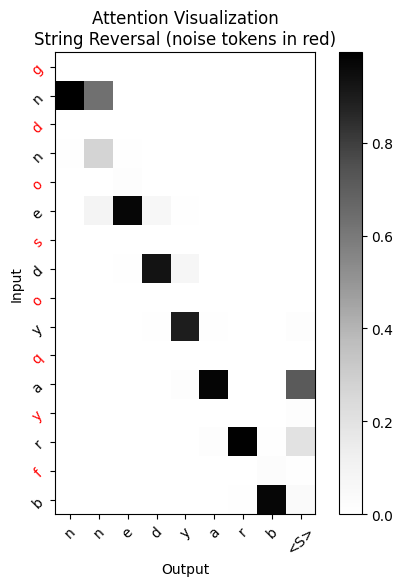

In [138]:
xtext = X_test[index]
xtext = [index_to_token[i] for i in xtext]
ytext = list(y) + ['<S>']

# Recall that each column is the attention weights for a token in the output
plt.figure(figsize=(6, 6))

plt.imshow(attentions, cmap='Greys')
# Matplot lib reverses the y-axis, so we need to reverse the labels
plt.gca().invert_yaxis()
plt.xticks(range(len(ytext)), ytext, rotation=45)

# Make the non-noise tokens blue in the yticks, and the noise tokens red
plt.yticks(range(len(xtext)), xtext, rotation=45)
for i, label in enumerate(plt.gca().get_yticklabels()):
    if i % 2 == 0:
        label.set_color('black')
    else:
        label.set_color('red')

plt.ylabel('Input')
plt.xlabel('Output')

plt.title('Attention Visualization\nString Reversal (noise tokens in red)')

plt.colorbar()
plt.savefig('attention.png', dpi=300)
plt.show()